# Soldani - Causal Graph Learning su Adult (dataset completo)

Questo notebook applica il modulo `src.discovery` a **tutte le colonne** del dataset Adult,
non solo alle 4 usate nel benchmark 2\_3. L'obiettivo e' verificare se l'algoritmo di
structure learning (HillClimbSearch + BDeu) riesce a scoprire automaticamente mediatori
e confondenti quando ha a disposizione piu' variabili.

## 1. Setup del path di progetto

In [14]:
from pathlib import Path
import sys

current = Path.cwd()
while current != current.parent:
    if (current / "src").exists():
        REPO_ROOT = current
        break
    current = current.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

## 2. Import

In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from src.graph import build_sfm
from src.discovery import discover_sfm, classify_roles, graph_similarity


ROLE_COLORS = {
    "mediator": "#4A90D9",
    "confounder": "#D94A4A",
    "irrelevant": "#AAAAAA",
}
X_COLOR = "#4AD97A"
Y_COLOR = "#D9A84A"
LEGEND = [
    Patch(facecolor=X_COLOR, label="X (protected)"),
    Patch(facecolor=Y_COLOR, label="Y (outcome)"),
    Patch(facecolor="#4A90D9", label="Mediator"),
    Patch(facecolor="#D94A4A", label="Confounder"),
    Patch(facecolor="#AAAAAA", label="Irrelevant"),
]


def plot_dag(dag, roles, protected, outcome, title="Learned DAG", ax=None):
    """Disegna un DAG colorato per ruolo."""
    show = False
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(14, 8))
        show = True

    colors = []
    for node in dag.nodes():
        if node == protected:
            colors.append(X_COLOR)
        elif node == outcome:
            colors.append(Y_COLOR)
        else:
            colors.append(ROLE_COLORS.get(roles.get(node, "irrelevant"), "#AAAAAA"))

    pos = nx.kamada_kawai_layout(dag)
    nx.draw_networkx_nodes(dag, pos, ax=ax, node_color=colors, node_size=2000)
    nx.draw_networkx_labels(dag, pos, ax=ax, font_size=7, font_weight="bold")
    nx.draw_networkx_edges(
        dag, pos, ax=ax, edge_color="#666666", width=1.5,
        arrows=True, arrowsize=20, connectionstyle="arc3,rad=0.05",
        min_source_margin=20, min_target_margin=20,
    )
    ax.set_title(title, fontsize=13)
    ax.legend(handles=LEGEND, loc="upper left", fontsize=8)

    if show:
        plt.tight_layout()
        plt.show()

## 3. Caricamento e preprocessing del dataset completo

Carichiamo tutte le 13 colonne di Adult. Le variabili numeriche con alta
cardinalita' (`S1_age`, `capital-gain`, `capital-loss`, `hours-per-week`)
vengono discretizzate in bin. `education` viene raggruppata in 5 fasce
come nel notebook 2\_3. `native-country` viene ridotta a 3 categorie
(US / Other / Unknown) per contenere la cardinalita'.

In [16]:
CSV_PATH = "../../data/processed/adult.csv"
PROTECTED = "S2_gender"
OUTCOME = "T_income"

df = pd.read_csv(CSV_PATH).dropna()
print(f"Shape originale: {df.shape}")
print(f"Colonne: {list(df.columns)}")
print()

# --- Binning variabili numeriche ---
df["S1_age"] = pd.cut(
    df["S1_age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["<=25", "26-35", "36-45", "46-55", ">55"],
    include_lowest=True,
)

df["hours-per-week"] = pd.cut(
    df["hours-per-week"],
    bins=[0, 20, 35, 45, 60, 100],
    labels=["<=20", "21-35", "36-45", "46-60", ">60"],
    include_lowest=True,
)

df["capital-gain"] = (df["capital-gain"] > 0).map({True: "yes", False: "no"})
df["capital-loss"] = (df["capital-loss"] > 0).map({True: "yes", False: "no"})

# --- Raggruppamento education (16 -> 5 fasce) ---
education_tiers = {
    "Preschool": "<HS", "1st-4th": "<HS", "5th-6th": "<HS", "7th-8th": "<HS",
    "9th": "<HS", "10th": "<HS", "11th": "<HS", "12th": "<HS",
    "HS-grad": "HS-grad",
    "Some-college": "Some-college", "Assoc-acdm": "Some-college", "Assoc-voc": "Some-college",
    "Bachelors": "Bachelors",
    "Masters": "Grad", "Prof-school": "Grad", "Doctorate": "Grad",
}
df["education"] = df["education"].map(education_tiers)

# --- Raggruppamento native-country (42 -> 3) ---
df["native-country"] = df["native-country"].apply(
    lambda x: "US" if x == "United-States" else "Other"
)

print(f"Shape dopo preprocessing: {df.shape}")
for c in df.columns:
    print(f"  {c}: {df[c].nunique()} livelli")

Shape originale: (48842, 13)
Colonne: ['S1_age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'S3_race', 'S2_gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'T_income']

Shape dopo preprocessing: (48842, 13)
  S1_age: 5 livelli
  workclass: 9 livelli
  education: 5 livelli
  marital-status: 7 livelli
  occupation: 15 livelli
  relationship: 6 livelli
  S3_race: 5 livelli
  S2_gender: 2 livelli
  capital-gain: 2 livelli
  capital-loss: 2 livelli
  hours-per-week: 5 livelli
  native-country: 2 livelli
  T_income: 2 livelli


## 4. Causal Graph Learning — dataset completo

Applichiamo `discover_sfm` a tutte le colonne. Il temporal\_order di default
(`[[X], [others], [Y]]`) mette `S2_gender` nel primo tier e `T_income`
nell'ultimo, lasciando tutte le altre variabili nel tier intermedio.

In [17]:
sfm_full, dag_full, roles_full = discover_sfm(
    data=df,
    sensitive_attr=PROTECTED,
    outcome_attr=OUTCOME,
    method="hc",
    score="bdeu",
)

print("Learned DAG edges:")
for u, v in dag_full.edges():
    print(f"  {u} -> {v}")

print(f"\nTotale archi: {dag_full.number_of_edges()}")
print(f"Totale nodi:  {dag_full.number_of_nodes()}")

print("\nRuoli scoperti:")
for node, role in sorted(roles_full.items(), key=lambda x: x[1]):
    print(f"  {node}: {role}")

mediators = [n for n, r in roles_full.items() if r == "mediator"]
confounders = [n for n, r in roles_full.items() if r == "confounder"]
irrelevant = [n for n, r in roles_full.items() if r == "irrelevant"]

print(f"\nMediators (W):   {mediators}")
print(f"Confounders (Z): {confounders}")
print(f"Irrelevant:      {irrelevant}")

2026-08-04 02:50:52.541 | DEBUG    | src.discovery:discover_graph:87 - Default temporal order: [['S2_gender'], ['S1_age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'S3_race', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'], ['T_income']]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S1_age': 'O', 'workclass': 'C', 'education': 'C', 'marital-status': 'C', 'occupation': 'C', 'relationship': 'C', 'S3_race': 'C', 'S2_gender': 'C', 'capital-gain': 'C', 'capital-loss': 'C', 'hours-per-week': 'O', 'native-country': 'C', 'T_income': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S1_age': 'O', 'workclass': 'C', 'education': 'C', 'marital-status': 'C', 'occupation': 'C', 'relationship': 'C', 'S3_race': 'C', 'S2_gender': 'C', 'capital-gain': 'C', 'capital-loss': 'C', 'hours-per-week': 'O', 'native-country': 'C', 'T_income

Learned DAG edges:
  S1_age -> workclass
  S1_age -> hours-per-week
  S1_age -> education
  workclass -> occupation
  education -> T_income
  education -> native-country
  education -> capital-gain
  education -> capital-loss
  marital-status -> S1_age
  occupation -> education
  occupation -> hours-per-week
  relationship -> marital-status
  relationship -> T_income
  relationship -> S1_age
  relationship -> S3_race
  relationship -> capital-gain
  relationship -> native-country
  relationship -> capital-loss
  S2_gender -> relationship
  S2_gender -> occupation
  S2_gender -> workclass
  S2_gender -> marital-status
  capital-gain -> T_income
  capital-loss -> capital-gain
  capital-loss -> T_income
  native-country -> S3_race

Totale archi: 26
Totale nodi:  13

Ruoli scoperti:
  S3_race: irrelevant
  hours-per-week: irrelevant
  native-country: irrelevant
  S1_age: mediator
  workclass: mediator
  education: mediator
  marital-status: mediator
  occupation: mediator
  relationship: m

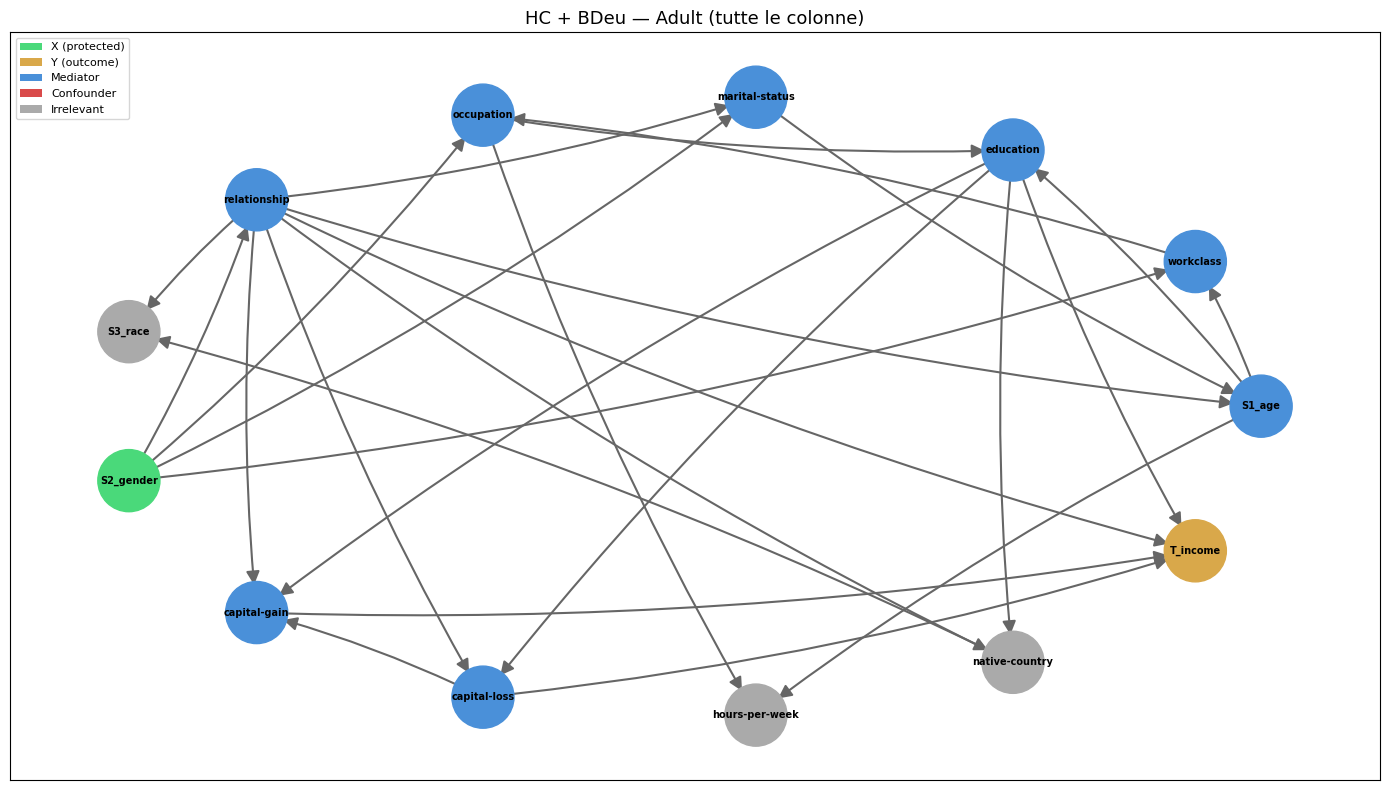

<Figure size 640x480 with 0 Axes>

In [18]:
plot_dag(dag_full, roles_full, PROTECTED, OUTCOME,
        title="HC + BDeu — Adult (tutte le colonne)")
plt.tight_layout()
plt.show()

## 5. Confronto con subset di 4 colonne

Ripetiamo il discovery sulle sole 4 colonne usate nel notebook 2\_3
per confrontare i ruoli scoperti.

In [19]:
df_4 = df[[PROTECTED, "education", "hours-per-week", OUTCOME]].copy()

sfm_4, dag_4, roles_4 = discover_sfm(
    data=df_4,
    sensitive_attr=PROTECTED,
    outcome_attr=OUTCOME,
    method="hc",
    score="bdeu",
)

print("=== 4 colonne ===")
print(f"Edges: {list(dag_4.edges())}")
print(f"Roles: {roles_4}")
print(f"Mediators: {[n for n,r in roles_4.items() if r=='mediator']}")
print(f"Confounders: {[n for n,r in roles_4.items() if r=='confounder']}")

print("\n=== Tutte le colonne ===")
print(f"Mediators: {mediators}")
print(f"Confounders: {confounders}")

sim = graph_similarity(sfm_4, sfm_full)
print(f"\nSimilarity SFM 4-col vs full: {sim}")

2026-08-04 02:50:53.381 | DEBUG    | src.discovery:discover_graph:87 - Default temporal order: [['S2_gender'], ['education', 'hours-per-week'], ['T_income']]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S2_gender': 'C', 'education': 'C', 'hours-per-week': 'O', 'T_income': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S2_gender': 'C', 'education': 'C', 'hours-per-week': 'O', 'T_income': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S2_gender': 'C', 'education': 'C', 'hours-per-week': 'O', 'T_income': 'C'}
2026-08-04 02:50:53.416 | DEBUG    | src.discovery:classify_roles:205 - Role classification for X=S2_gender, Y=T_income: {'education': 'mediator', 'hours-per-week': 'mediator'}
2026-08-04 02:50:53.417 | INFO     | src.discovery:discover_sfm:302 - Discovered SFM: X=S2_gender, Y=T_income, Z=[], W=

=== 4 colonne ===
Edges: [('S2_gender', 'hours-per-week'), ('S2_gender', 'T_income'), ('S2_gender', 'education'), ('education', 'T_income'), ('hours-per-week', 'education'), ('hours-per-week', 'T_income')]
Roles: {'education': 'mediator', 'hours-per-week': 'mediator'}
Mediators: ['education', 'hours-per-week']
Confounders: []

=== Tutte le colonne ===
Mediators: ['S1_age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'capital-gain', 'capital-loss']
Confounders: []

Similarity SFM 4-col vs full: {'shd': 24, 'precision': 0.125, 'recall': 0.5, 'f1': 0.2, 'jaccard': 0.1111}


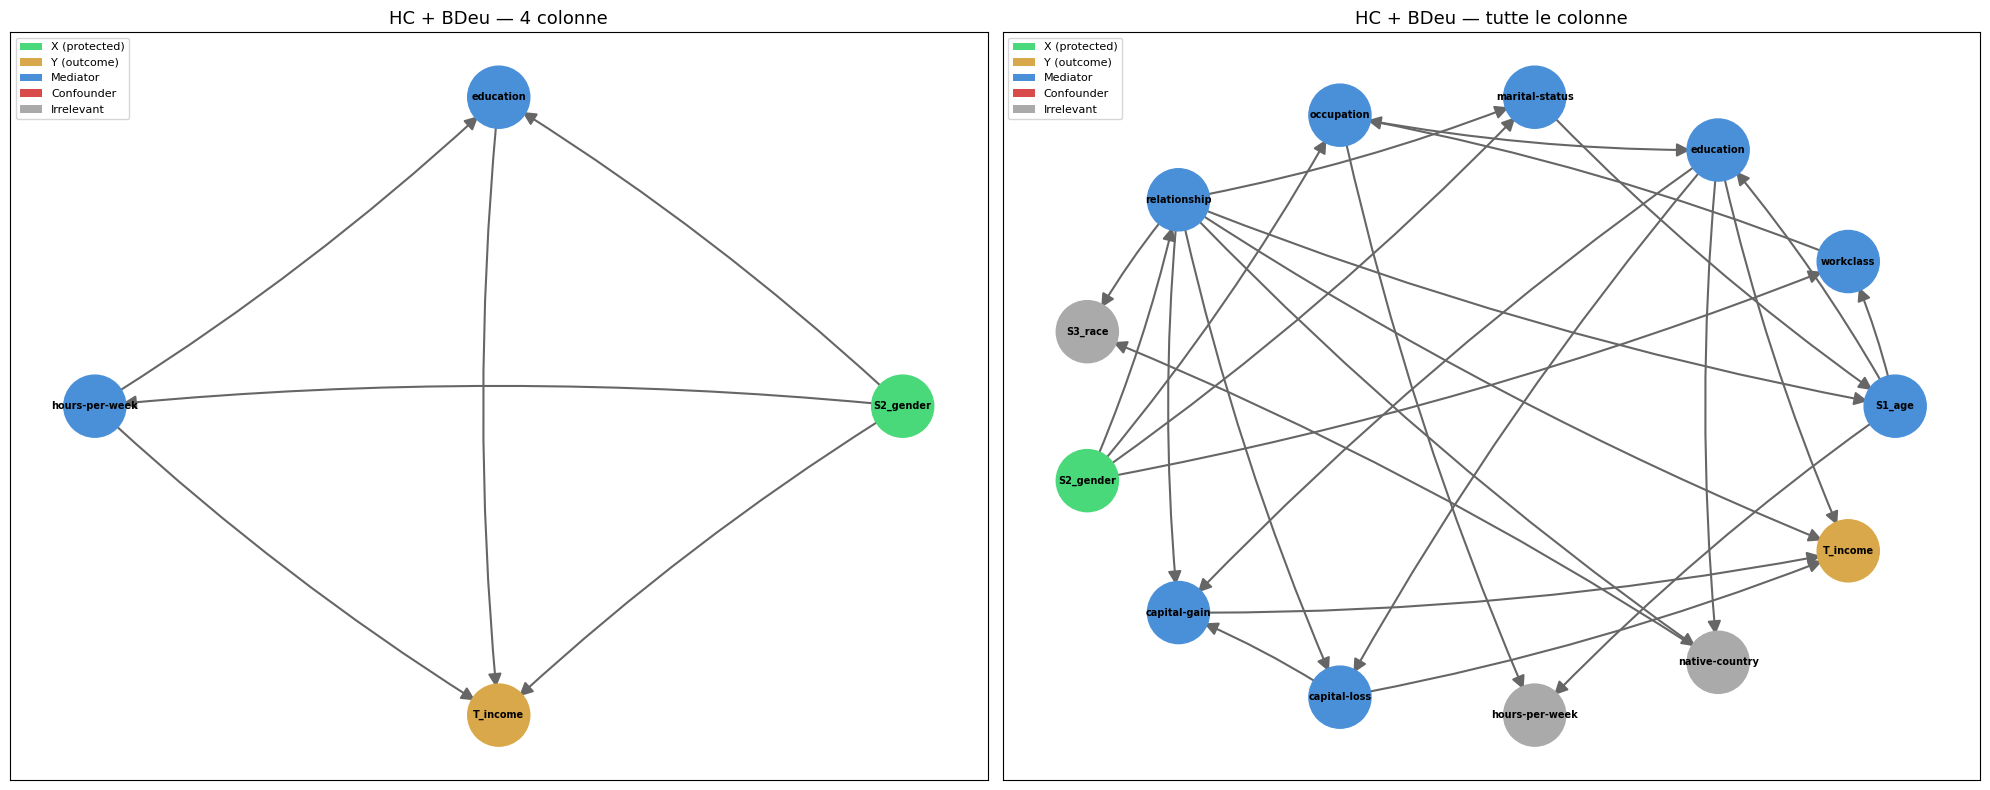

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_dag(dag_4, roles_4, PROTECTED, OUTCOME,
         title="HC + BDeu — 4 colonne", ax=axes[0])
plot_dag(dag_full, roles_full, PROTECTED, OUTCOME,
         title="HC + BDeu — tutte le colonne", ax=axes[1])
plt.tight_layout()
plt.show()

## 6. Confronto tra scoring functions

Testiamo HC con BDeu, BIC e K2 per verificare quanto i ruoli scoperti
dipendano dalla scelta della scoring function.

In [21]:
score_results = {}
score_dags = {}

for score_fn in ["bdeu", "bic", "k2"]:
    sfm_s, dag_s, roles_s = discover_sfm(
        data=df,
        sensitive_attr=PROTECTED,
        outcome_attr=OUTCOME,
        method="hc",
        score=score_fn,
    )
    m = [n for n, r in roles_s.items() if r == "mediator"]
    c = [n for n, r in roles_s.items() if r == "confounder"]
    score_results[score_fn] = {
        "mediators": m, "confounders": c,
        "n_edges": dag_s.number_of_edges(),
        "roles": roles_s, "dag": dag_s,
    }
    print(f"=== HC + {score_fn.upper()} ===")
    print(f"  Edges: {dag_s.number_of_edges()}")
    print(f"  Mediators:   {m}")
    print(f"  Confounders: {c}")
    print()

# Tabella riassuntiva
summary = pd.DataFrame({
    k: {"mediators": v["mediators"], "confounders": v["confounders"], "n_edges": v["n_edges"]}
    for k, v in score_results.items()
}).T
print(summary.to_string())

2026-08-04 02:50:53.598 | DEBUG    | src.discovery:discover_graph:87 - Default temporal order: [['S2_gender'], ['S1_age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'S3_race', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'], ['T_income']]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S1_age': 'O', 'workclass': 'C', 'education': 'C', 'marital-status': 'C', 'occupation': 'C', 'relationship': 'C', 'S3_race': 'C', 'S2_gender': 'C', 'capital-gain': 'C', 'capital-loss': 'C', 'hours-per-week': 'O', 'native-country': 'C', 'T_income': 'C'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'S1_age': 'O', 'workclass': 'C', 'education': 'C', 'marital-status': 'C', 'occupation': 'C', 'relationship': 'C', 'S3_race': 'C', 'S2_gender': 'C', 'capital-gain': 'C', 'capital-loss': 'C', 'hours-per-week': 'O', 'native-country': 'C', 'T_income

=== HC + BDEU ===
  Edges: 26
  Mediators:   ['S1_age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'capital-gain', 'capital-loss']
  Confounders: []



2026-08-04 02:50:54.925 | DEBUG    | src.discovery:classify_roles:205 - Role classification for X=S2_gender, Y=T_income: {'S1_age': 'mediator', 'workclass': 'mediator', 'education': 'mediator', 'marital-status': 'mediator', 'occupation': 'mediator', 'relationship': 'mediator', 'S3_race': 'irrelevant', 'capital-gain': 'mediator', 'capital-loss': 'irrelevant', 'hours-per-week': 'irrelevant', 'native-country': 'irrelevant'}
2026-08-04 02:50:54.926 | INFO     | src.discovery:discover_sfm:302 - Discovered SFM: X=S2_gender, Y=T_income, Z=[], W=['relationship', 'marital-status', 'S1_age', 'workclass', 'occupation', 'education', 'capital-gain']
2026-08-04 02:50:54.931 | DEBUG    | src.discovery:discover_graph:87 - Default temporal order: [['S2_gender'], ['S1_age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'S3_race', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'], ['T_income']]
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Cat

=== HC + BIC ===
  Edges: 23
  Mediators:   ['S1_age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'capital-gain']
  Confounders: []



2026-08-04 02:50:56.783 | DEBUG    | src.discovery:classify_roles:205 - Role classification for X=S2_gender, Y=T_income: {'S1_age': 'mediator', 'workclass': 'mediator', 'education': 'mediator', 'marital-status': 'mediator', 'occupation': 'irrelevant', 'relationship': 'mediator', 'S3_race': 'mediator', 'capital-gain': 'mediator', 'capital-loss': 'mediator', 'hours-per-week': 'mediator', 'native-country': 'mediator'}
2026-08-04 02:50:56.783 | INFO     | src.discovery:discover_sfm:302 - Discovered SFM: X=S2_gender, Y=T_income, Z=[], W=['relationship', 'capital-loss', 'marital-status', 'capital-gain', 'native-country', 'S3_race', 'hours-per-week', 'workclass', 'S1_age', 'education']


=== HC + K2 ===
  Edges: 64
  Mediators:   ['S1_age', 'workclass', 'education', 'marital-status', 'relationship', 'S3_race', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
  Confounders: []

                                                                                                                              mediators confounders n_edges
bdeu                               [S1_age, workclass, education, marital-status, occupation, relationship, capital-gain, capital-loss]          []      26
bic                                              [S1_age, workclass, education, marital-status, occupation, relationship, capital-gain]          []      23
k2    [S1_age, workclass, education, marital-status, relationship, S3_race, capital-gain, capital-loss, hours-per-week, native-country]          []      64


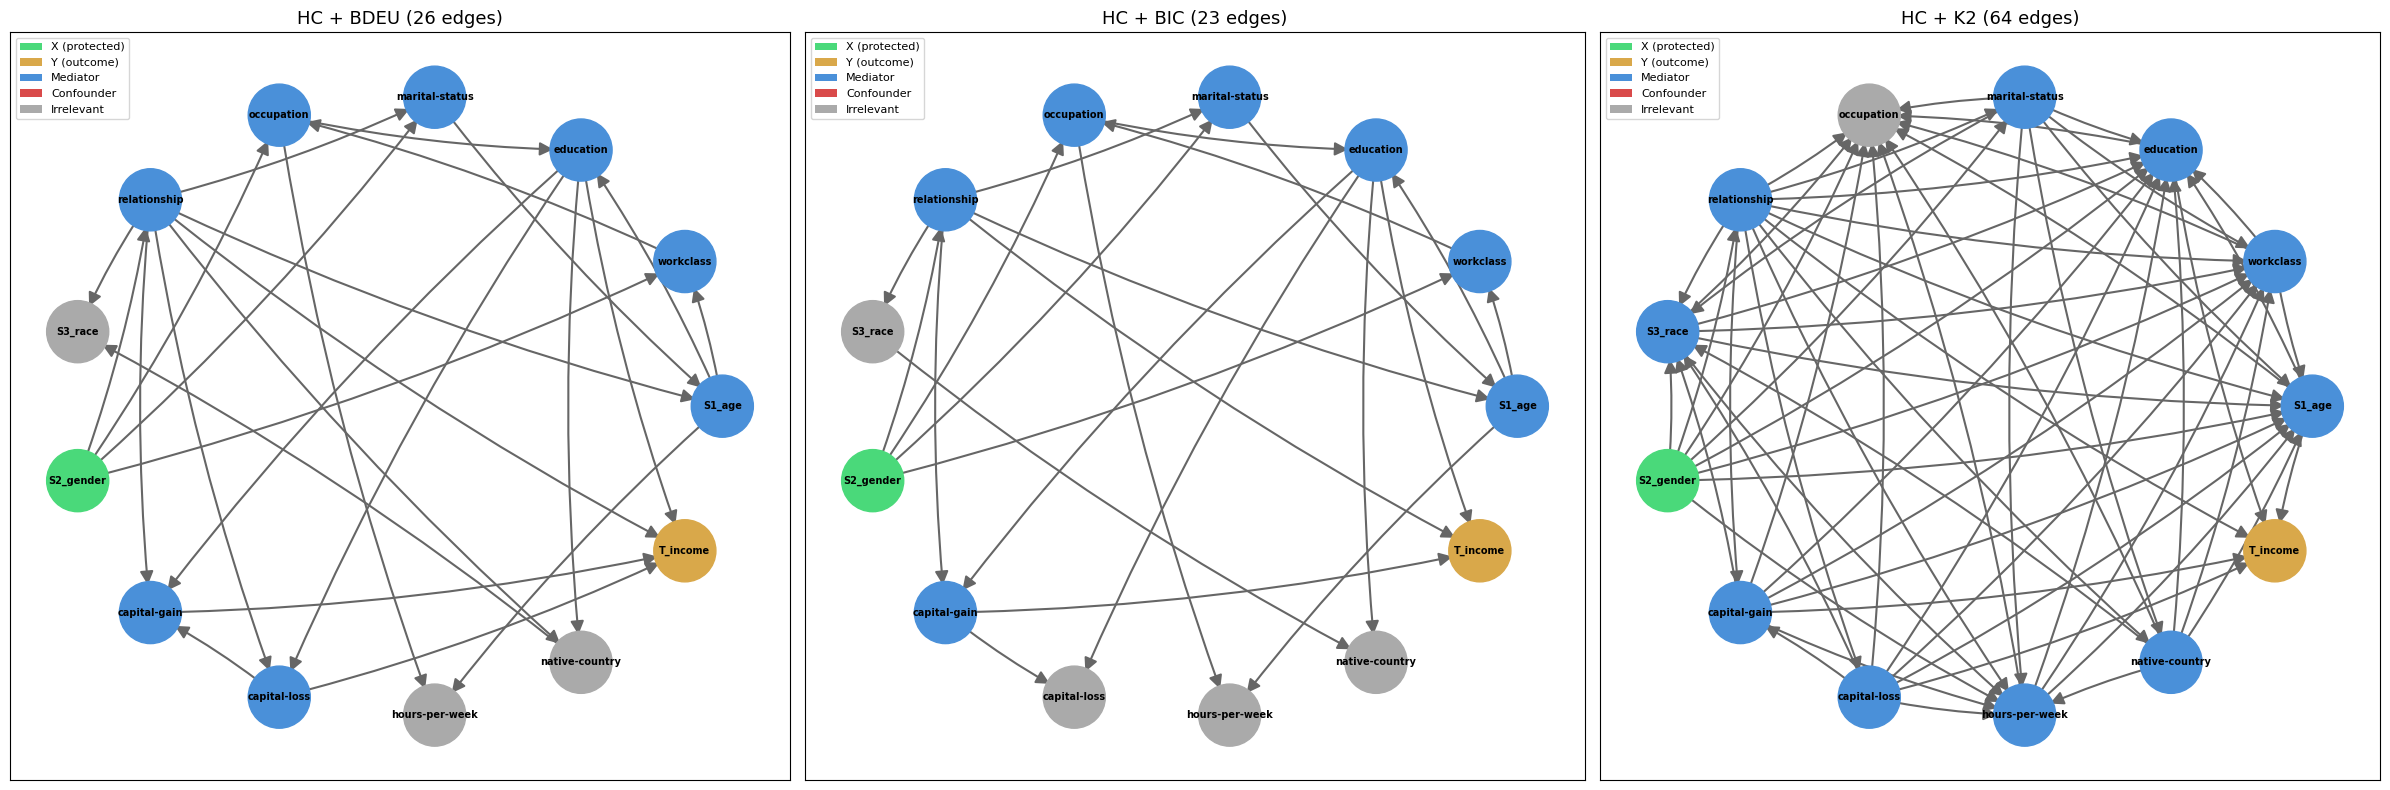

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, (score_fn, res) in zip(axes, score_results.items()):
    plot_dag(res["dag"], res["roles"], PROTECTED, OUTCOME,
             title=f"HC + {score_fn.upper()} ({res['n_edges']} edges)", ax=ax)
plt.tight_layout()
plt.show()

## 7. Confronto con il grafo esperto (manuale)

Costruiamo il grafo esperto usato nelle versioni precedenti del benchmark
(education = confounder, hours-per-week = mediator) e calcoliamo le metriche
di similarita' rispetto al grafo scoperto automaticamente.

In [23]:
expert_sfm = build_sfm(
    sensitive_attr=PROTECTED,
    outcome_attr=OUTCOME,
    confounder_attrs=["education"],
    mediator_attrs=["hours-per-week"],
)

print("Expert graph edges:")
for u, v in expert_sfm.edges():
    print(f"  {u} -> {v}")

sim_full = graph_similarity(expert_sfm, sfm_full)
sim_4 = graph_similarity(expert_sfm, sfm_4)

print(f"\nSimilarity expert vs full-discovery: {sim_full}")
print(f"Similarity expert vs 4-col-discovery: {sim_4}")

Expert graph edges:
  S2_gender -> T_income
  S2_gender -> hours-per-week
  education -> S2_gender
  education -> T_income
  education -> hours-per-week
  hours-per-week -> T_income

Similarity expert vs full-discovery: {'shd': 26, 'precision': 0.0833, 'recall': 0.3333, 'f1': 0.1333, 'jaccard': 0.0714}
Similarity expert vs 4-col-discovery: {'shd': 4, 'precision': 0.6667, 'recall': 0.6667, 'f1': 0.6667, 'jaccard': 0.5}


## 9. Riepilogo

Tabella riassuntiva con i ruoli scoperti per ogni variabile,
confrontando il discovery su 4 colonne vs tutte le colonne.

In [24]:
all_vars = sorted(set(list(roles_full.keys()) + list(roles_4.keys())))

summary_rows = []
for var in all_vars:
    summary_rows.append({
        "variable": var,
        "role_4col": roles_4.get(var, "—"),
        "role_full": roles_full.get(var, "—"),
        "match": roles_4.get(var) == roles_full.get(var) if var in roles_4 else "—",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

      variable role_4col  role_full match
        S1_age         —   mediator     —
       S3_race         — irrelevant     —
  capital-gain         —   mediator     —
  capital-loss         —   mediator     —
     education  mediator   mediator  True
hours-per-week  mediator irrelevant False
marital-status         —   mediator     —
native-country         — irrelevant     —
    occupation         —   mediator     —
  relationship         —   mediator     —
     workclass         —   mediator     —
